<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# 📓 Diagramm-Manipulation Part 3:

Visualisierung in Stil eines Piktogramms, skaliert nach relativen Häufigkeiten.

In [43]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Bild laden (muss transparenten Hintergrund haben!)
img = mpimg.imread("../resources/person.png")

# Farbtöne (RGBA)
farben = {
    "Selbstständige": [0.3, 0.7, 1.0, 1.0],
    "Angestellte": [0.4, 0.9, 0.4, 1.0],
    "Beamte": [1.0, 0.6, 0.3, 1.0],
    "Arbeiter": [0.9, 0.3, 0.4, 1.0],
}

# Daten

| Beschäftigunsverhältnis               | Relative Häufigkeit|
| ---------------------- | ---------------------------- |
| Selbstständige         | 20 |
| Angestellte            | 40 |
| Beamte                 | 15 |
| Arbeiter               | 25 |


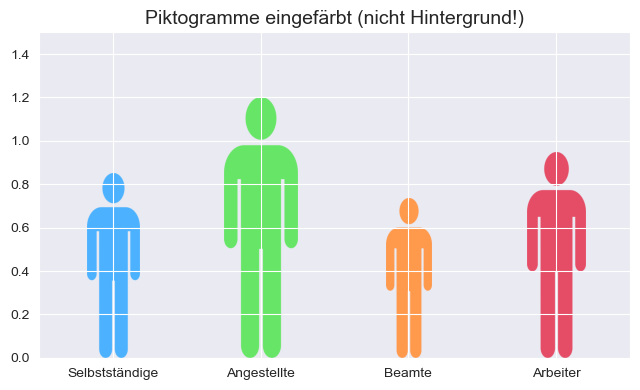

In [70]:
labels = list(farben.keys())
values = np.array([20, 40, 15, 25])
max_val = values.max()
xs = np.arange(len(labels)) + 1

# --- Piktogramme einfügen ---
fig, ax = plt.subplots(figsize=(6.5, 4))

for x, (label, color), value in zip(xs, farben.items(), values):
    scale = np.sqrt(value / max_val)

    # Farbige Kopie des Icons erzeugen (RGB multiplizieren mit Farbe)
    recolored = img.copy()
    mask = recolored[..., 3] > 0  # transparente Bereiche filtern
    for c in range(3):  # RGB-Kanäle färben
        recolored[..., c] = recolored[..., c] * color[c]

    ax.imshow(
        recolored,
        extent=[x - 0.25*scale, x + 0.25*scale, 0, 1.2*scale],
        aspect="auto"
    )

ax.set_xlim(0.5, len(labels) + 0.5)
ax.set_ylim(0, 1.5)
ax.axis("on")
ax.set_xticks(xs, labels)
ax.set_title("Piktogramme eingefärbt (nicht Hintergrund!)", fontsize=14)
plt.tight_layout()
plt.show()

💡 Bei der Darstellung mit Piktogrammen sollten die Werte der Datenreihe dem Flächeninhalt des Piktogramms entsprechen.

Für einen Wert, der halb so groß ist wie ein anderer Wert, muss also nicht die Höhe des Piktogramms halbiert werden, sondern der Flächeninhalt.

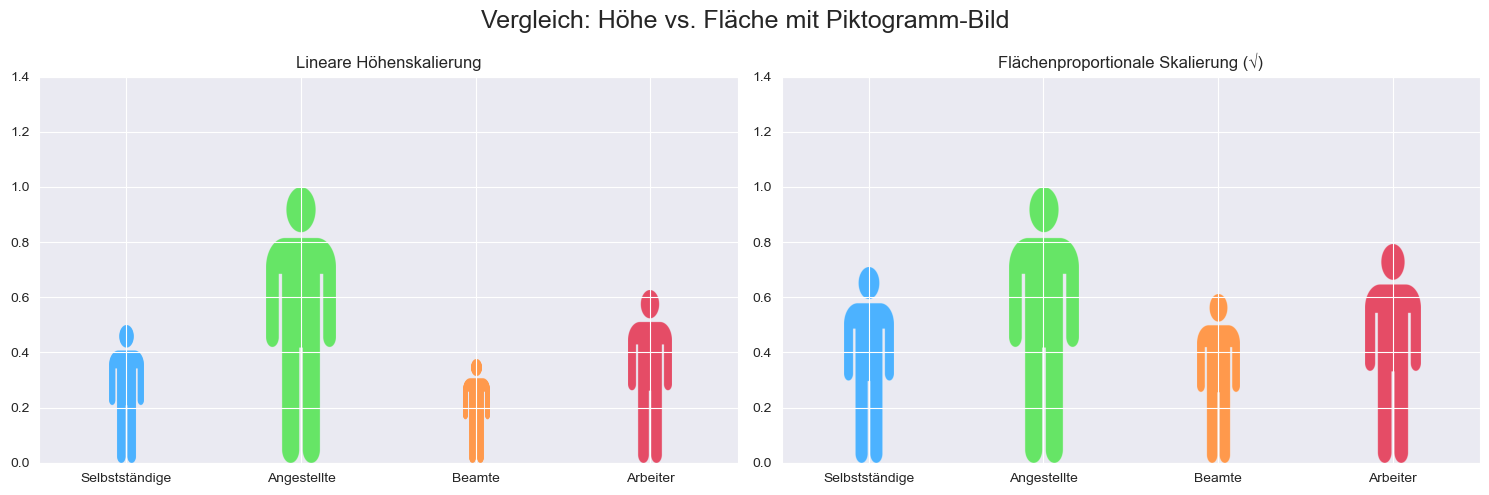

In [71]:
# Beispielwerte
labels = list(farben.keys())
values = np.array([20, 40, 15, 25])
max_val = values.max()
xs = np.arange(len(labels)) + 1

# Bild laden (transparentes Piktogramm, z. B. PNG)
img = mpimg.imread("../resources/person.png")


# Figuren vorbereiten
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# 1️⃣ Lineare Höhenskalierung
for x, (label, color), value in zip(xs, farben.items(), values):
#for x, v in zip(xs, values):
    scale = value / max_val  # linear

    # Farbige Kopie des Icons erzeugen (RGB multiplizieren mit Farbe)
    recolored = img.copy()
    mask = recolored[..., 3] > 0  # transparente Bereiche filtern
    for c in range(3):  # RGB-Kanäle färben
        recolored[..., c] = recolored[..., c] * color[c]

    axs[0].imshow(recolored, extent=[x-0.2*scale, x+0.2*scale, 0, 1*scale], aspect='auto')

axs[0].set_title("Lineare Höhenskalierung")
axs[0].set_xlim(0.5, len(labels)+0.5)
axs[0].set_ylim(0, 1.4)
axs[0].axis("on")
axs[0].set_xticks(xs, labels)


# 2️⃣ Flächenproportionale Skalierung (√)
for x, (label, color), value in zip(xs, farben.items(), values):
#for x, v in zip(xs, values):
    scale = np.sqrt(value / max_val)
    axs[1].imshow(img, extent=[x-0.2*scale, x+0.2*scale, 0, 1*scale], aspect='auto')

    # Farbige Kopie des Icons erzeugen (RGB multiplizieren mit Farbe)
    recolored = img.copy()
    mask = recolored[..., 3] > 0  # transparente Bereiche filtern
    for c in range(3):  # RGB-Kanäle färben
        recolored[..., c] = recolored[..., c] * color[c]

    axs[1].imshow(recolored, extent=[x-0.2*scale, x+0.2*scale, 0, 1*scale], aspect='auto')

axs[1].set_title("Flächenproportionale Skalierung (√)")
axs[1].set_xlim(0.5, len(labels)+0.5)
axs[1].set_ylim(0, 1.4)
axs[1].axis("on")
axs[1].set_xticks(xs, labels)

plt.suptitle("Vergleich: Höhe vs. Fläche mit Piktogramm-Bild", fontsize=18)
plt.tight_layout()
plt.show()


| Variante               | Berechnung                   | Wahrnehmung                                        |
| ---------------------- | ---------------------------- | -------------------------------------------------- |
| **Höhen-skalierung**   | Höhe ∝ Wert                  | wirkt „dramatisch“, kleine Werte scheinen zu klein |
| **Flächen-skalierung** | Fläche ∝ Wert → Höhe ∝ √Wert | realistischere Wahrnehmung der Anteile             |


# Prozentrechnen

Werden Statistiken durch die Angabe von Prozentsätzen ausgewertet, kommt es darauf an, welcher Grundwert verwendet wird.
Wird eine falsche Basis verwendet, können die Prozentwerte extrem groß oder extrem klein werden.

Frau Müller liest in einem Prospekt eines Pharmaherstellers folgendes:
* **„Das Sterberisiko bei Herz-Kreislauf-Erkrankungen wird durch die Einnahme des Medikaments Prosal um 33,3 Prozent verringert.“**

💡 `Was Frau Müller nicht weiß ist, dass der Pharmaherstellers die ‚relative Risikoverminderung‘ angibt. D.h., senkt ein Medikament beispielsweise die Sterberate von ursprünglich sechs von 1000 Personen auf vier von 1000 Personen, so hat sich das Sterberisiko scheinbar durch die Einnahme dieser Tabletten um 33.3 % verringert.
Betrachtet man die absoluten Zahlen, dann bleiben durch die Einnahme des Medikaments zwei von 1000 Personen mehr am Leben, als ohne die Behandlung. Das entspricht einer Verringerung der Anzahl der Herz-Kreislauf-Toten um 0.2 %.`


# Rätsel

Der Eiffelturm ist 300m hoch und wiegt 8000t. Wieviel wöge der Eiffelturm, wenn er 30cm hoch wäre?

# Quellen
* https://de.bettermarks.com/mathe/manipulationen/